In [1]:
import os
import pandas
import numpy as np
import matplotlib.pyplot as plt

In [4]:
config_num = 2
topk_cats = 5

results_dir = os.path.join(f'./results/category_decoding_results_c{config_num}_top{topk_cats}.csv')
result_df = pandas.read_csv(results_dir)
result_df.head()   

,subject_id,n_samples,n_classes,C1_acc_mean,C1_acc_std,C1_chance_mean,C1_n_channels,C1_n_timepoints,EPN_acc_mean,EPN_acc_std,...,P2_acc_mean,P2_acc_std,P2_chance_mean,P2_n_channels,P2_n_timepoints,P3b_acc_mean,P3b_acc_std,P3b_chance_mean,P3b_n_channels,P3b_n_timepoints
0,1,4280,5,0.325000,0.008141,0.264019,3,16,0.394159,0.018197,...,0.334579,0.005656,0.264019,7,25,0.375467,0.007557,0.264019,7,76
1,2,4280,5,0.308411,0.013361,0.264019,3,16,0.370327,0.007125,...,0.286449,0.009813,0.264019,7,25,0.337383,0.007329,0.264019,7,76
2,3,4280,5,0.344159,0.023090,0.264019,3,16,0.397196,0.010859,...,0.330140,0.011532,0.264019,7,25,0.337617,0.018938,0.264019,7,76
3,4,4280,5,0.317056,0.019501,0.264019,3,16,0.403037,0.021630,...,0.321495,0.012891,0.264019,7,25,0.400935,0.018741,0.264019,7,76
4,5,4280,5,0.338084,0.014953,0.264019,3,16,0.387617,0.017160,...,0.326168,0.018059,0.264019,7,25,0.334346,0.011239,0.264019,7,76


In [ ]:
# extract erp component names
erp_comp_names = [col for col in result_df.columns if col.endswith('_acc_mean')]
erp_comp_names = [col.replace('_acc_mean', '') for col in erp_comp_names]

['C1', 'EPN', 'LPC', 'N1', 'N170', 'N2', 'N400', 'P1', 'P2', 'P3b']

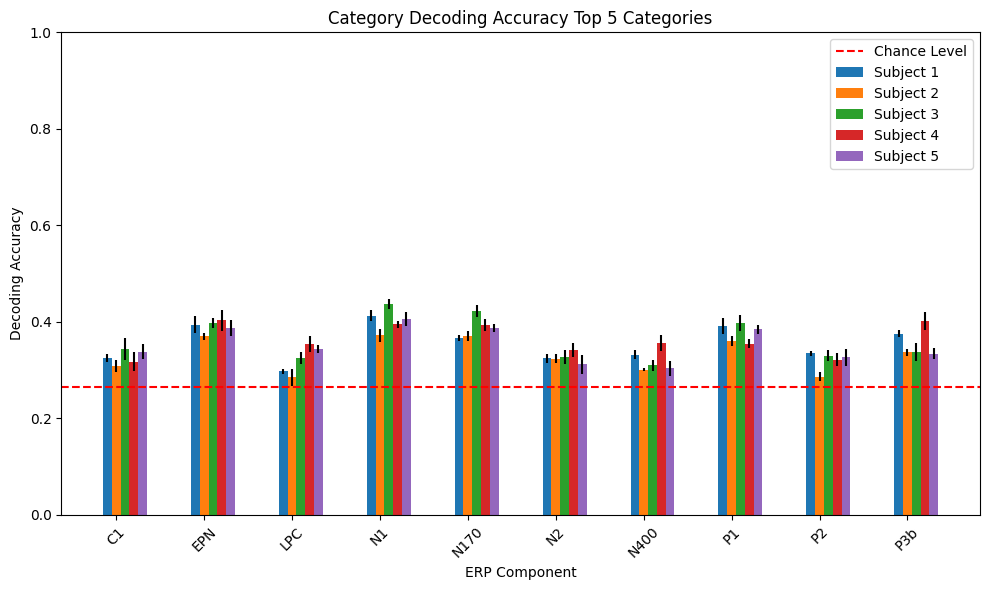

In [16]:
num_comps = len(erp_comp_names)
x = np.arange(num_comps)

# plot grouped bar chat where each x tick is an erp and each bar is a subject's decoding accuracy for that comp
plt.figure(figsize=(10, 6))

# loop through each subject and plot a bar for each erp component
for i, row in result_df.iterrows():
    accs = [row[f'{comp}_acc_mean'] for comp in erp_comp_names]
    stds = [row[f'{comp}_acc_std'] for comp in erp_comp_names]
    plt.bar(x + i*0.1, accs, width=0.1, label=f'Subject {int(row["subject_id"])}', yerr=stds)   
     
plt.xticks(x + 0.1, erp_comp_names, rotation=45)
plt.xlabel('ERP Component')
plt.ylabel('Decoding Accuracy')
plt.ylim(0, 1)
plt.axhline(result_df.iloc[0]['C1_chance_mean'], color='red', linestyle='--', label='Chance Level')
plt.title(f'Category Decoding Accuracy Top {topk_cats} Categories')
plt.legend()
plt.tight_layout()
